Heavily based on https://github.com/vitessce/vitessce-python/blob/main/demos/human-lymph-node-10x-visium/src/create_zarr.py

In [2]:
import scanpy as sc
import numpy as np
import scipy.cluster
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import json
from vitessce.data_utils import (
    to_diamond,
    rgb_img_to_ome_zarr,
    optimize_adata,
)

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.10/dist-packages/vitessce/__init__.py:42: UserWarning: Extra installs are necessary to use widgets: No module named 'anywidget'
  warn(f'Extra installs are necessary to use widgets: {e}')
/usr/local/lib/python3.10/dist-packages/vitessce/__init__.py:68: UserWarning: Extra installs are necessary to use exports: No module named 'starlette'
  warn(f'Extra installs are necessary to use exports: {e}')


In [3]:
sample_name = "DLPFC_Br8667_mid_manual_alignment_all"
BAYESSPACE_CLUSTERS_DIR = '/data/zusers/kresgeb/psych_encode/spatialDLPFC/processed-data/rdata/spe/clustering_results'
source_dir = f'/data/zusers/kresgeb/psych_encode/spatialDLPFC/processed-data/rerun_spaceranger/{sample_name}/outs'
output_dir = '/zata/public_html/users/kresgeb/sample01'
output_img = os.path.join(output_dir, 'image.ome.zarr')
output_adata = os.path.join(output_dir, 'data.h5ad.zarr')

sc.settings.set_figure_params(dpi=80, facecolor="white")
sc.settings.verbosity = 3

In [4]:
adata = sq.read.visium(source_dir)
adata.var_names_make_unique()
adata

reading /data/zusers/kresgeb/psych_encode/spatialDLPFC/processed-data/rerun_spaceranger/DLPFC_Br8667_mid_manual_alignment_all/outs/filtered_feature_bc_matrix.h5
 (0:00:00)


/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 4265 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [5]:
# Calculate QC metrics
adata.var_names_make_unique()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

adata

AnnData object with n_obs × n_vars = 4265 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'

<Axes: xlabel='n_genes_by_counts', ylabel='Count'>

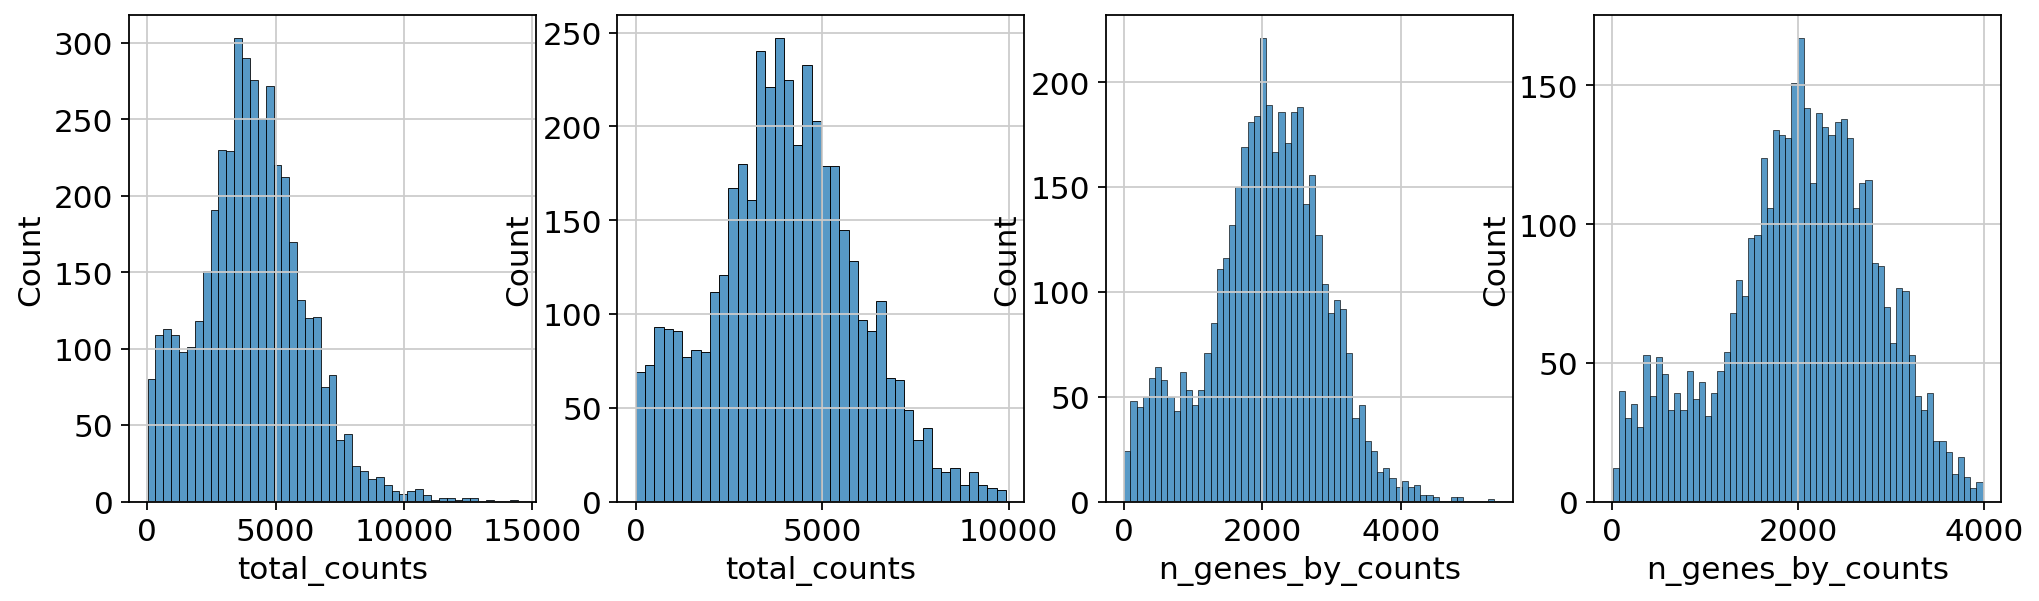

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(
    adata.obs["total_counts"][adata.obs["total_counts"] < 10000],
    kde=False,
    bins=40,
    ax=axs[1],
)
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.histplot(
    adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 4000],
    kde=False,
    bins=60,
    ax=axs[3],
)

normalizing counts per cell
    finished (0:00:00)


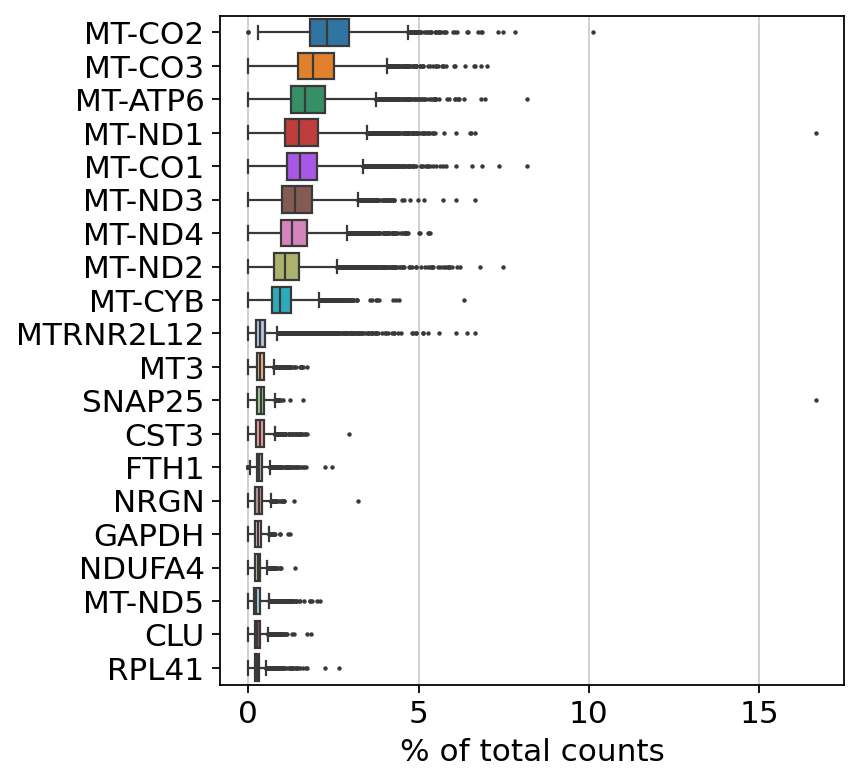

In [7]:
sc.pl.highest_expr_genes(adata, n_top=20)

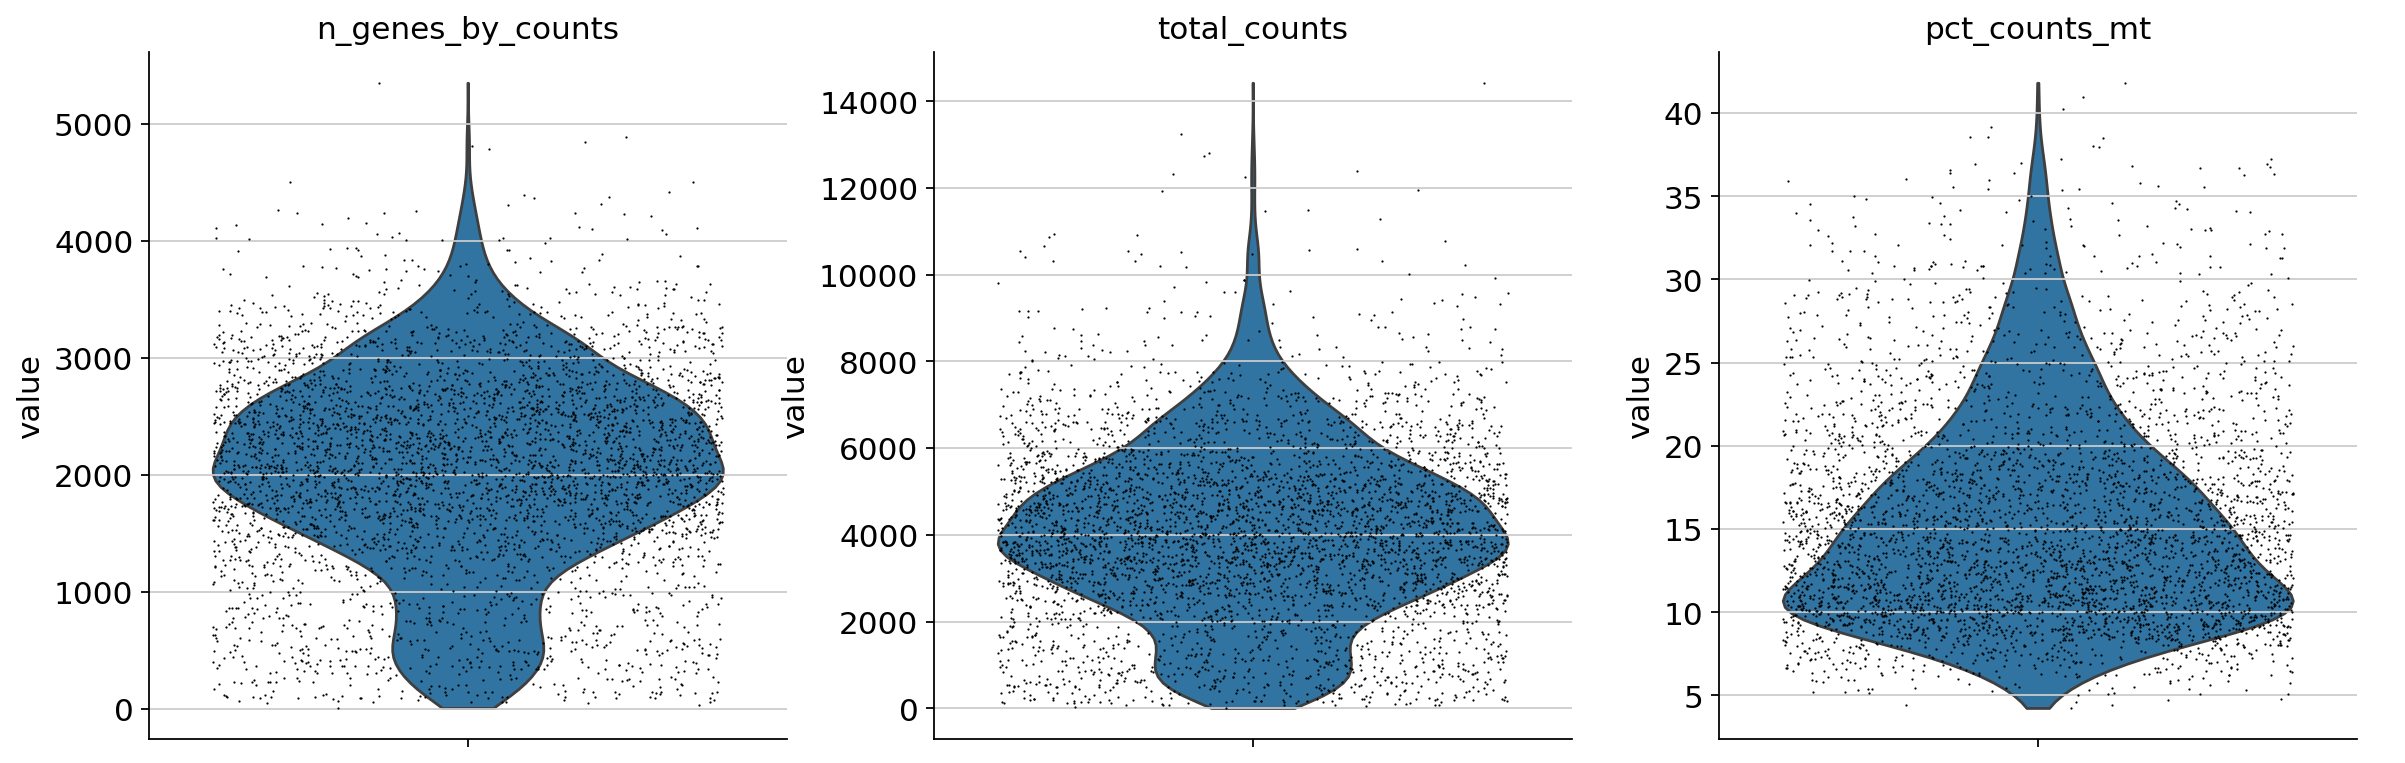

In [8]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

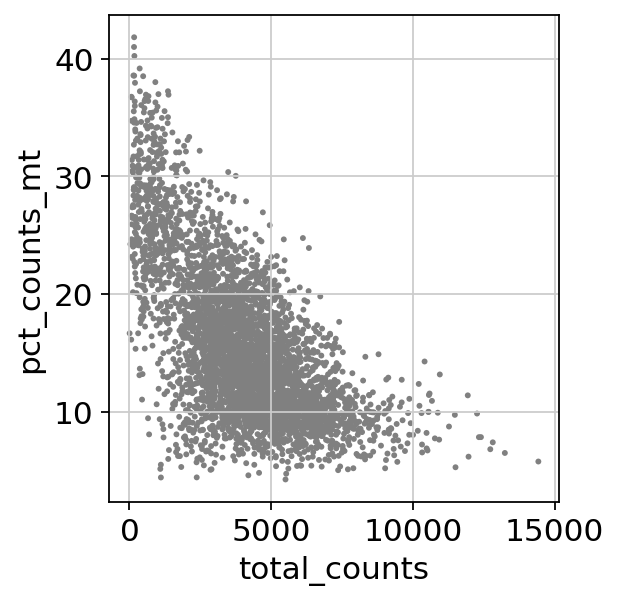

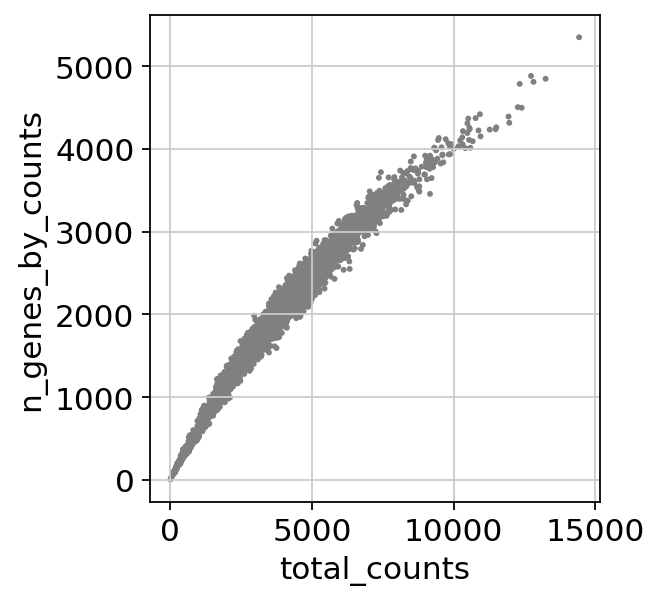

In [9]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [10]:
# Perform basic filtering (much more generous than source)
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=10)
adata = adata[adata.obs["pct_counts_mt"] < 30]
adata

filtered out 27 cells that have less than 100 genes expressed
filtered out 19679 genes that are detected in less than 10 cells


View of AnnData object with n_obs × n_vars = 4109 × 16922
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'

In [11]:
def set_genes_of_interest(adata, whitelist_path):
    adata.var['genes_of_interest'] = adata.var['highly_variable'].copy()
    with open(whitelist_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith('#') and line in adata.var.index:
                adata.var.loc[line, 'genes_of_interest'] = True


In [12]:
# Perform normalization
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)

# Determine the top 300 highly variable genes.
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=300)
set_genes_of_interest(adata, '/zata/zippy/kresgeb/psych_screen/whitelist.txt')

adata

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


/usr/local/lib/python3.10/dist-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


AnnData object with n_obs × n_vars = 4109 × 16922
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'genes_of_interest'
    uns: 'spatial', 'log1p', 'hvg'
    obsm: 'spatial'

In [13]:
# Dimensionality reduction and clustering
sc.pp.pca(adata, mask_var='genes_of_interest')
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="leiden", flavor="igraph", n_iterations=2)
print(adata.obs['leiden'])
print(type(adata.obs['leiden']))
adata

computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50


2025-03-11 18:57:31.486897: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-11 18:57:31.499491: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741719451.512815 1693288 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741719451.516933 1693288 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-11 18:57:31.533429: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)
running Leiden clustering
    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
AAACAACGAATAGTTC-1    0
AAACAAGTATCTCCCA-1    1
AAACAATCTACTAGCA-1    3
AAACACCAATAACTGC-1    0
AAACAGAGCGACTCCT-1    4
                     ..
TTGTTTCACATCCAGG-1    1
TTGTTTCATTAGTCTA-1    0
TTGTTTCCATACAACT-1    0
TTGTTTGTATTACACG-1    3
TTGTTTGTGTAAATTC-1    1
Name: leiden, Length: 4109, dtype: category
Categories (8, object): ['0', '1', '2', '3', '4', '5', '6', '7']
<class 'pandas.core.series.Series'>


AnnData object with n_obs × n_vars = 4109 × 16922
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'genes_of_interest'
    uns: 'spatial', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [35]:
# TODO improve efficiency, currently opens and searches the clusters.csv once for EACH sample--despite having the data for ALL samples
# This compounds for more entries in k_tuple
# TODO change to save under one obs entry (bayes_space) with multiple columns where each column is a resolution (simpler and MAY be better for performance/compression?)
def add_cluster_data(adata, sample_name, k_tuple=(9,)):
    # The shortened name that exists in the clustering results csv
    # Ex. Br8667_mid
    sample_id = "_".join(sample_name.split("_")[1:3])

    for k in k_tuple:
        # Read the data from clusters.csv
        clusters_path = os.path.join(
            BAYESSPACE_CLUSTERS_DIR, f"bayesSpace_harmony_{k}", "clusters.csv"
        )
        full_cluster_data = pd.read_csv(clusters_path)

        # Extract only the relevant data
        filtered_cluster_data = full_cluster_data[
            full_cluster_data["key"].str.contains(sample_id)
        ].copy()
        filtered_cluster_data.loc[:, "cell_id"] = filtered_cluster_data["key"].apply(
            lambda x: x.split("_")[0]
        )
        filtered_cluster_data = filtered_cluster_data[["cell_id", "cluster"]]
        filtered_cluster_data.set_index("cell_id", inplace=True)

        # Convert to format as found in leiden
        filtered_cluster_data = (
            filtered_cluster_data.astype(int).astype(str).astype("category")
        )

        # Rename the clusters to something more easy for user to understand
        rename_dict = {
            str(i): f"Spatial Domain {int(k):02d}D{int(i):02d}" for i in range(1, k + 1)
        }
        print(rename_dict)

        filtered_cluster_data["cluster"] = filtered_cluster_data["cluster"].cat.rename_categories(rename_dict)
        print(filtered_cluster_data["cluster"])

        # Add the data to the AnnData object
        adata.obs[f"bayes_space_k={k}"] = adata.obs_names.map(
            filtered_cluster_data["cluster"]
        )

In [36]:
add_cluster_data(adata, sample_name, k_tuple=(9,16,28))

{'1': 'Spatial Domain 09D01', '2': 'Spatial Domain 09D02', '3': 'Spatial Domain 09D03', '4': 'Spatial Domain 09D04', '5': 'Spatial Domain 09D05', '6': 'Spatial Domain 09D06', '7': 'Spatial Domain 09D07', '8': 'Spatial Domain 09D08', '9': 'Spatial Domain 09D09'}
cell_id
AAACAACGAATAGTTC-1    Spatial Domain 09D07
AAACAAGTATCTCCCA-1    Spatial Domain 09D03
AAACAATCTACTAGCA-1    Spatial Domain 09D08
AAACACCAATAACTGC-1    Spatial Domain 09D04
AAACAGAGCGACTCCT-1    Spatial Domain 09D04
                              ...         
TTGTTTCACATCCAGG-1    Spatial Domain 09D05
TTGTTTCATTAGTCTA-1    Spatial Domain 09D08
TTGTTTCCATACAACT-1    Spatial Domain 09D04
TTGTTTGTATTACACG-1    Spatial Domain 09D02
TTGTTTGTGTAAATTC-1    Spatial Domain 09D05
Name: cluster, Length: 3939, dtype: category
Categories (9, object): ['Spatial Domain 09D01', 'Spatial Domain 09D02', 'Spatial Domain 09D03', 'Spatial Domain 09D04', ..., 'Spatial Domain 09D06', 'Spatial Domain 09D07', 'Spatial Domain 09D08', 'Spatial Domai

In [16]:
# Hierarchical clustering of genes for optimal gene ordering
# X_hvg_arr = adata[:, adata.var['highly_variable']].X.toarray()
# X_hvg_index = adata[:, adata.var['highly_variable']].var.copy().index
# Z = scipy.cluster.hierarchy.linkage(X_hvg_arr.T, method="average", optimal_ordering=True)
X_goi_arr = adata[:, adata.var['genes_of_interest']].X.toarray()
X_goi_index = adata[:, adata.var['genes_of_interest']].var.copy().index
Z = scipy.cluster.hierarchy.linkage(X_goi_arr.T, method='average', optimal_ordering=True)
adata

AnnData object with n_obs × n_vars = 4109 × 16922
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'bayes_space_k=9'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'genes_of_interest'
    uns: 'spatial', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [17]:
# Get the hierarchy-based ordering of genes.
num_cells = adata.obs.shape[0]
# highly_var_index_ordering = scipy.cluster.hierarchy.leaves_list(Z)
# highly_var_genes = X_hvg_index.values[highly_var_index_ordering].tolist()
goi_index_ordering = scipy.cluster.hierarchy.leaves_list(Z)
genes_of_interest = X_goi_index.values[goi_index_ordering].tolist()

all_genes = adata.var.index.values.tolist()
# not_var_genes = adata.var.loc[~adata.var['highly_variable']].index.values.tolist()
not_goi = adata.var.loc[~adata.var['genes_of_interest']].index.values.tolist()

In [18]:
def get_orig_index(gene_id):
    return all_genes.index(gene_id)

# var_index_ordering = list(map(get_orig_index, highly_var_genes)) + list(map(get_orig_index, not_var_genes))
var_index_ordering = list(map(get_orig_index, genes_of_interest)) + list(map(get_orig_index, not_goi))

In [19]:
# Create a new *ordered* gene expression dataframe.
adata = adata[:, var_index_ordering].copy()
# adata.obsm["X_hvg"] = adata[:, adata.var['highly_variable']].X.copy()
adata.obsm["X_goi"] = adata[:, adata.var['genes_of_interest']].X.copy()

adata

AnnData object with n_obs × n_vars = 4109 × 16922
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'bayes_space_k=9'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'genes_of_interest'
    uns: 'spatial', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_goi'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [20]:
def get_scale_factor(sample_name):
    json_path = os.path.join(source_dir, 'spatial', 'scalefactors_json.json')
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data.get('tissue_hires_scalef')

In [21]:
scale_factor = get_scale_factor(sample_name)
adata.obsm['spatial'] = (adata.obsm['spatial'] * scale_factor)

adata.obsm['segmentations'] = np.zeros((num_cells, 4, 2))
radius = 8
for i in range(num_cells):
    adata.obsm['segmentations'][i, :, :] = to_diamond(adata.obsm['spatial'][i, 0], adata.obsm['spatial'][i, 1], radius)

adata

AnnData object with n_obs × n_vars = 4109 × 16922
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'bayes_space_k=9'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'genes_of_interest'
    uns: 'spatial', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_goi', 'segmentations'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [22]:
# Write img_arr to OME-Zarr.
# Need to convert images from interleaved to non-interleaved (color axis should be first).
img_hires = adata.uns['spatial'][sample_name]['images']['hires']
img_arr = np.transpose(img_hires, (2, 0, 1))

rgb_img_to_ome_zarr(img_arr, output_img, axes="cyx", chunks=(1, 256, 256), img_name="H & E Image")

In [23]:
adata = optimize_adata(
    adata,
    obs_cols=["leiden"],
    var_cols=["highly_variable", "genes_of_interest"],
    # obsm_keys=["X_hvg", "spatial", "segmentations", "X_umap", "X_pca"],
    obsm_keys=["X_goi", "spatial", "segmentations", "X_umap", "X_pca"],
    optimize_X=True,
    # Vitessce plays nicely with dense matrices saved with chunking
    # and this one is small enough that dense is not a huge overhead.
    to_dense_X=True,
)
adata.write_zarr(output_adata, chunks=[adata.shape[0], 10])